# Evaluation Visualization
Aggregates evaluation metrics per model for each date/file cohort in `~final` and plots grouped bar charts.
Cohorts: 2025-11-29 models, 2025-11-30 RAG models, and the 2025-11-30 baseline model.


In [69]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt

# Location of evaluation result CSVs
DATA_DIR = Path('~final')
CSV_FILES = sorted(DATA_DIR.glob('*_responses.csv'))
print(f'Found {len(CSV_FILES)} CSV files')

# Mapping of metric columns to display names, grouped for plotting
METRIC_GROUPS = {
    'Accuracy': [
        ('bedrock_correctness', 'Correctness'),
        ('bedrock_faithfulness', 'Faithfulness'),
        ('bedrock_citation_precision', 'Citation precision'),
        ('bedrock_citation_coverage', 'Citation coverage'),
        ('bedrock_completeness', 'Completeness'),
        ('nvidia_answer_accuracy', 'NVIDIA answer accuracy'),
    ],
    'Actionability': [
        ('bedrock_logical_coherence', 'Coherence'),
        ('bedrock_helpfulness', 'Helpfulness'),
        ('bedrock_refusal', 'Refusal'),
        ('bedrock_relevance', 'Relevance'),
        ('bedrock_harmfulness', 'Harmfulness'),
        ('bedrock_stereotyping', 'Stereotyping'),
    ],
    'Readability': [
        ('flesch_grade', 'Flesch grade'),
        ('flesch_reading_ease_score', 'Flesch readability'),
    ],
    'Sentiment': [
        ('nltk_sentiment', 'NLTK sentiment'),
    ],
}

# Desired cohort ordering for plotting
FILE_GROUP_ORDER = [
    '2025-11-29 models',
    '2025-11-30 RAG models',
    '2025-11-30 baseline',
]

def normalize_model_name(identifier) -> str:
    text = str(identifier).lower()
    if 'claude' in text:
        return 'Claude'
    if 'gpt' in text:
        return 'GPT'
    if 'llama' in text:
        return 'Llama'
    return str(identifier)


def categorize_file(path: Path) -> str:
    name = path.name
    if '2025-11-29' in name:
        return 'Small gold dataset'
    if '2025-11-30' in name and 'baseline' in name:
        return 'No RAG baseline'
    if '2025-11-30' in name:
        return 'Full gold dataset'
    return 'Other'

rows = []
for csv_path in CSV_FILES:
    file_group = categorize_file(csv_path)
    df = pd.read_csv(csv_path)

    if file_group == 'No RAG baseline' and 'model_id' in df.columns:
        # baseline file has multiple models; aggregate per model_id
        for model_id, sub_df in df.groupby('model_id'):
            model = normalize_model_name(model_id)
            numeric = sub_df.select_dtypes(include='number')
            for group_name, metrics in METRIC_GROUPS.items():
                for col, label in metrics:
                    if col not in numeric.columns:
                        continue
                    rows.append({
                        'file_group': file_group,
                        'group': group_name,
                        'metric': label,
                        'model': model,
                        'avg_value': numeric[col].mean(),
                    })
    else:
        model = normalize_model_name(csv_path.stem)
        numeric = df.select_dtypes(include='number')
        for group_name, metrics in METRIC_GROUPS.items():
            for col, label in metrics:
                if col not in numeric.columns:
                    continue
                rows.append({
                    'file_group': file_group,
                    'group': group_name,
                    'metric': label,
                    'model': model,
                    'avg_value': numeric[col].mean(),
                })

# Ensure columns exist even if no data aggregated
agg_df = pd.DataFrame(rows, columns=['file_group', 'group', 'metric', 'model', 'avg_value'])

if agg_df.empty:
    print('Warning: No aggregated rows found; check CSV contents and metric column names.')
else:
    # Enforce intended metric ordering within each group for plotting
    for group_name, metrics in METRIC_GROUPS.items():
        order = [label for _, label in metrics]
        mask = agg_df['group'] == group_name
        agg_df.loc[mask, 'metric'] = pd.Categorical(agg_df.loc[mask, 'metric'], categories=order, ordered=True)

agg_df.head()


Found 7 CSV files


,file_group,group,metric,model,avg_value
0,Small gold dataset,Accuracy,Correctness,Claude,0.952941
1,Small gold dataset,Accuracy,Faithfulness,Claude,0.914706
2,Small gold dataset,Accuracy,Citation precision,Claude,0.602941
3,Small gold dataset,Accuracy,Citation coverage,Claude,0.550000
4,Small gold dataset,Accuracy,Completeness,Claude,0.932353


In [70]:
def plot_group_for_file_group(file_group: str, metric_group: str, figsize=(12, 6)):
    subset = agg_df[(agg_df['file_group'] == file_group) & (agg_df['group'] == metric_group)].copy()
    if subset.empty:
        print(f'No data for {file_group} / {metric_group}')
        return

    order = [label for _, label in METRIC_GROUPS[metric_group]]
    subset['metric'] = pd.Categorical(subset['metric'], categories=order, ordered=True)
    subset = subset.sort_values('metric')

    pivot = subset.pivot(index='metric', columns='model', values='avg_value')
    ax = pivot.plot(kind='bar', figsize=figsize, rot=45)
    ax.set_title(f'{metric_group} metrics by model — {file_group}')
    ax.set_xlabel('Metric')
    ax.set_ylabel('Average value')
    ax.legend(title='Model')
    plt.tight_layout()
    plt.show()


### Small gold dataset — Accuracy


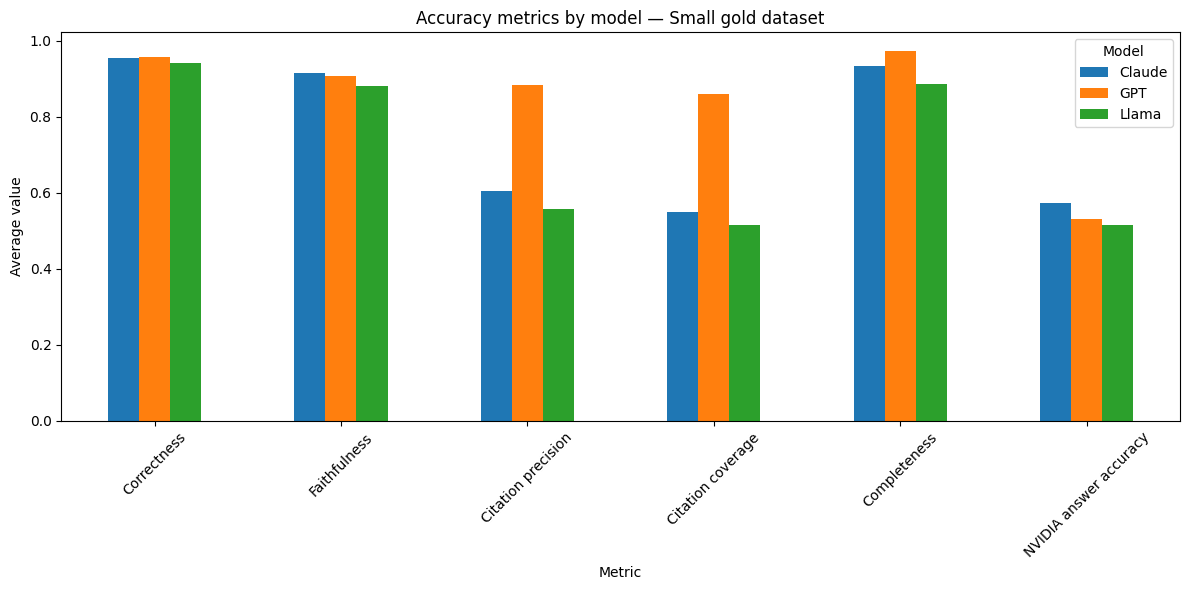

In [71]:
plot_group_for_file_group('Small gold dataset', 'Accuracy', figsize=(12, 6))


### Small gold dataset — Actionability


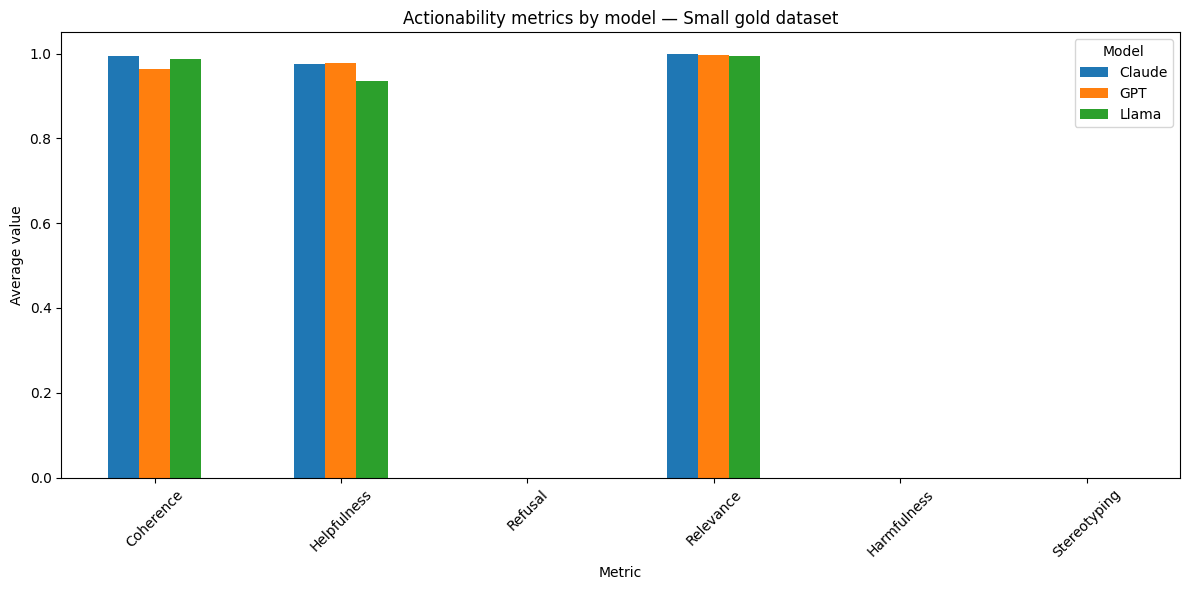

In [72]:
plot_group_for_file_group('Small gold dataset', 'Actionability', figsize=(12, 6))


### Small gold dataset — Readability


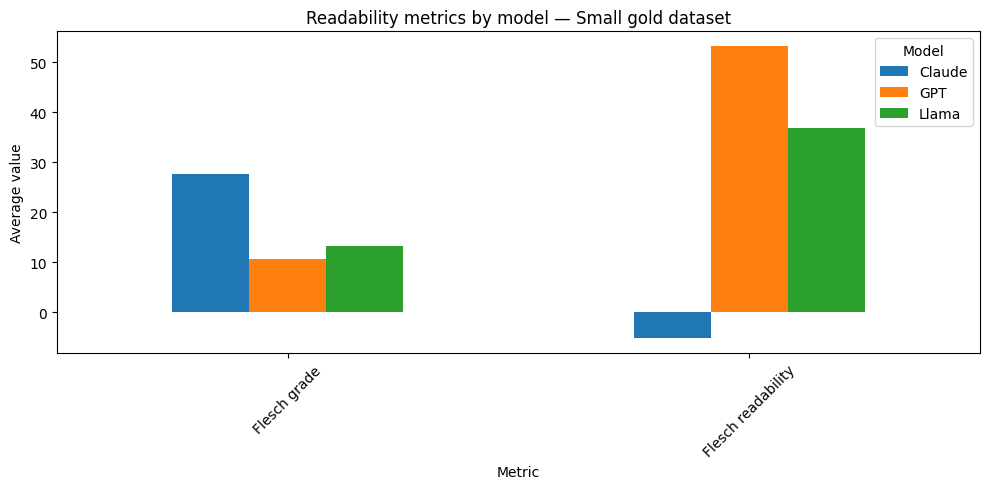

In [73]:
plot_group_for_file_group('Small gold dataset', 'Readability', figsize=(10, 5))


### Small gold dataset — Sentiment


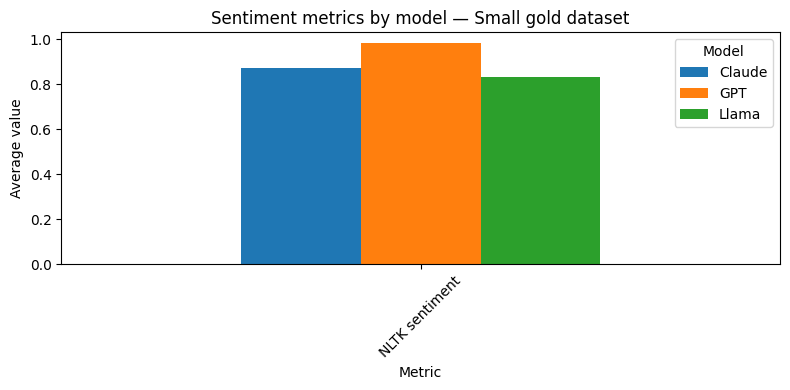

In [74]:
plot_group_for_file_group('Small gold dataset', 'Sentiment', figsize=(8, 4))


### Full gold dataset — Accuracy


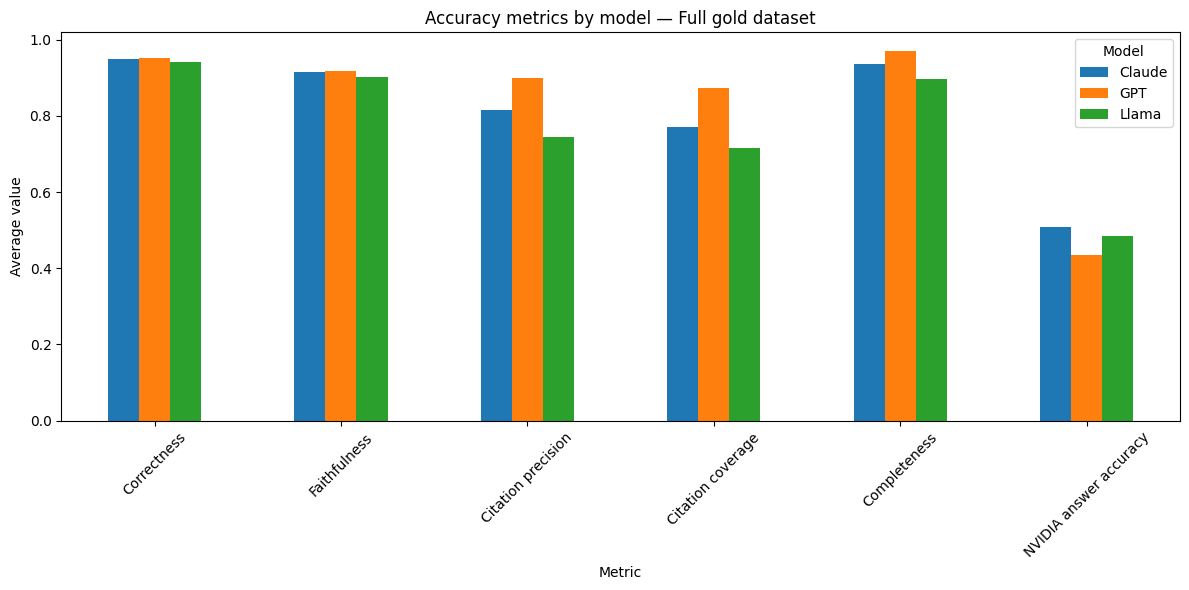

In [75]:
plot_group_for_file_group('Full gold dataset', 'Accuracy', figsize=(12, 6))


### Full gold dataset — Actionability


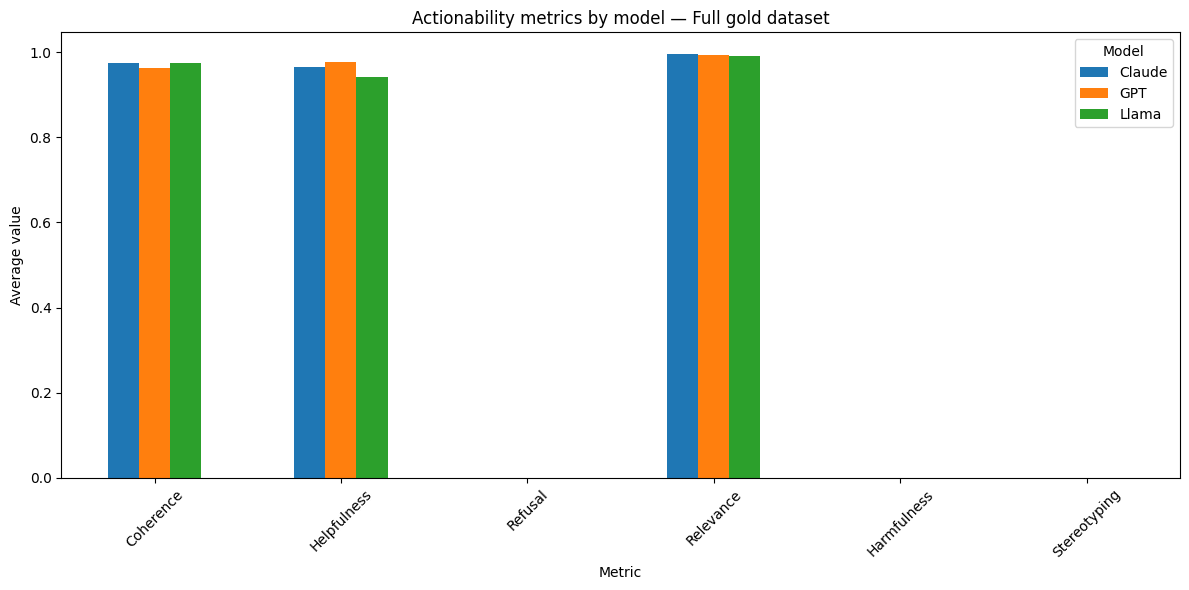

In [76]:
plot_group_for_file_group('Full gold dataset', 'Actionability', figsize=(12, 6))


### Full gold dataset — Readability


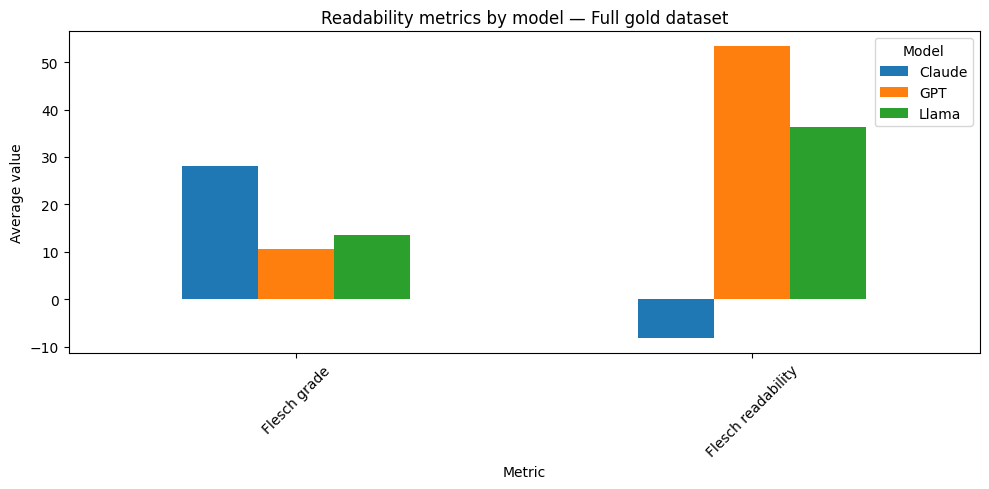

In [77]:
plot_group_for_file_group('Full gold dataset', 'Readability', figsize=(10, 5))


### Full gold dataset — Sentiment


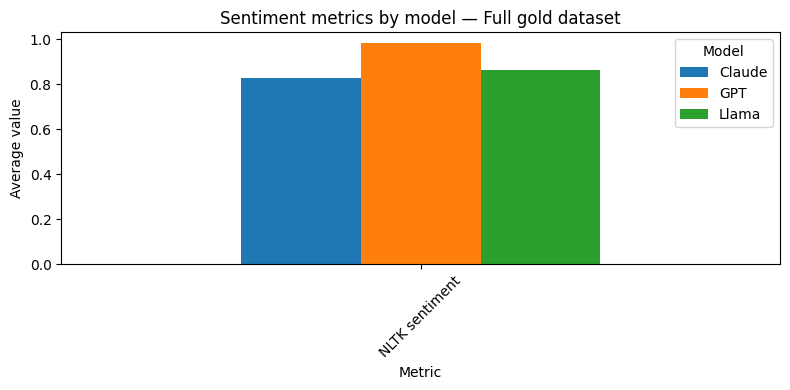

In [78]:
plot_group_for_file_group('Full gold dataset', 'Sentiment', figsize=(8, 4))


### No RAG baseline — Accuracy


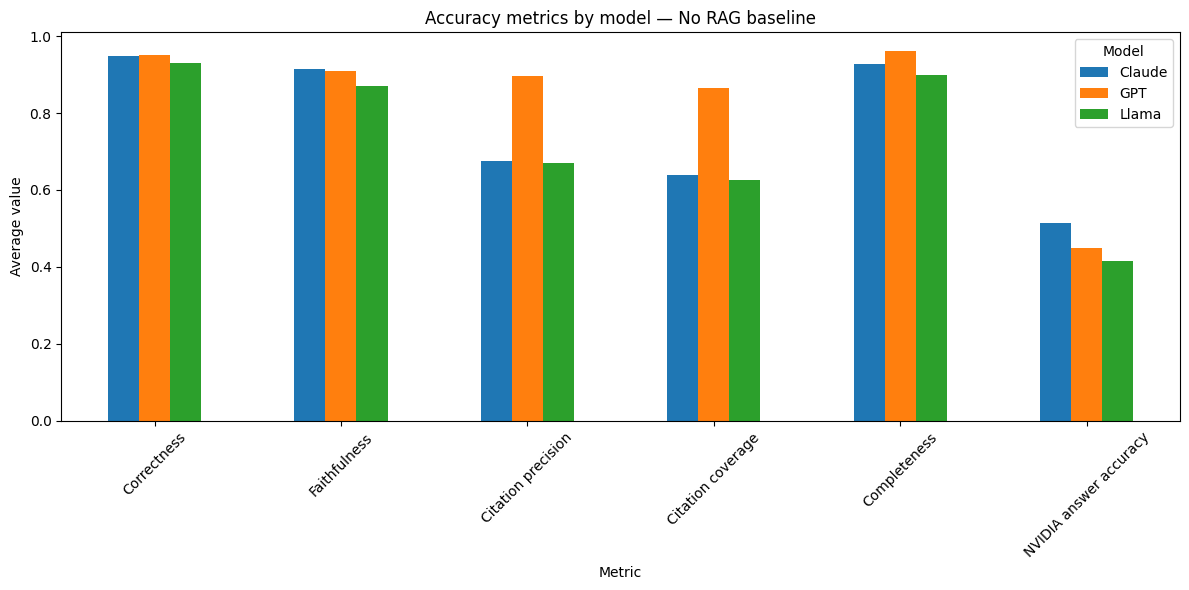

In [79]:
plot_group_for_file_group('No RAG baseline', 'Accuracy', figsize=(12, 6))


### No RAG baseline — Actionability


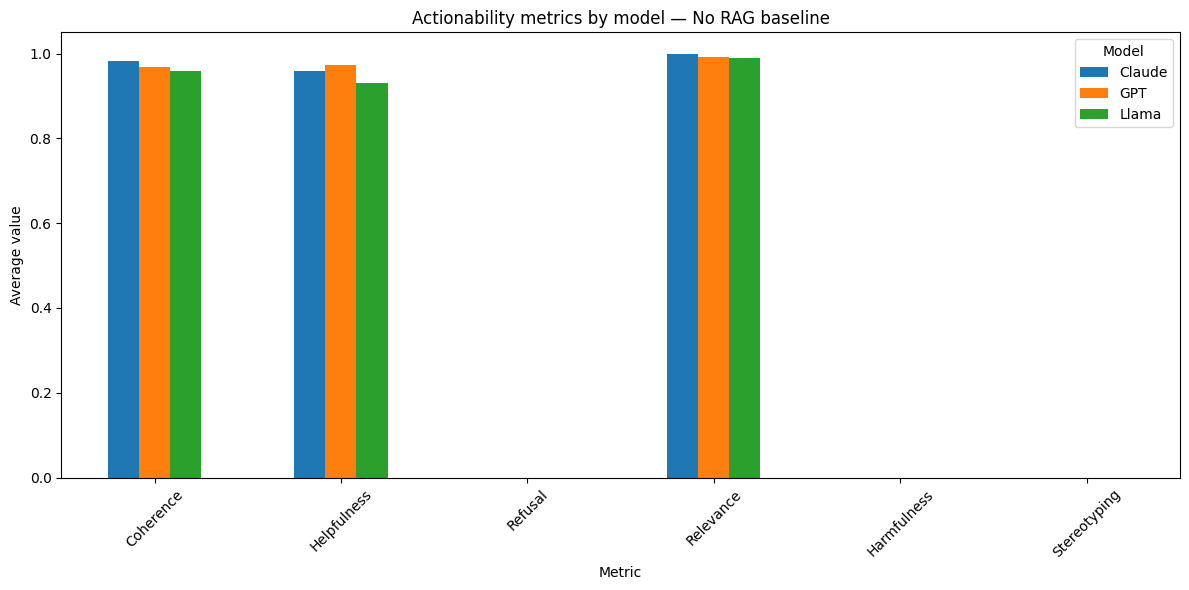

In [80]:
plot_group_for_file_group('No RAG baseline', 'Actionability', figsize=(12, 6))


### No RAG baseline — Readability


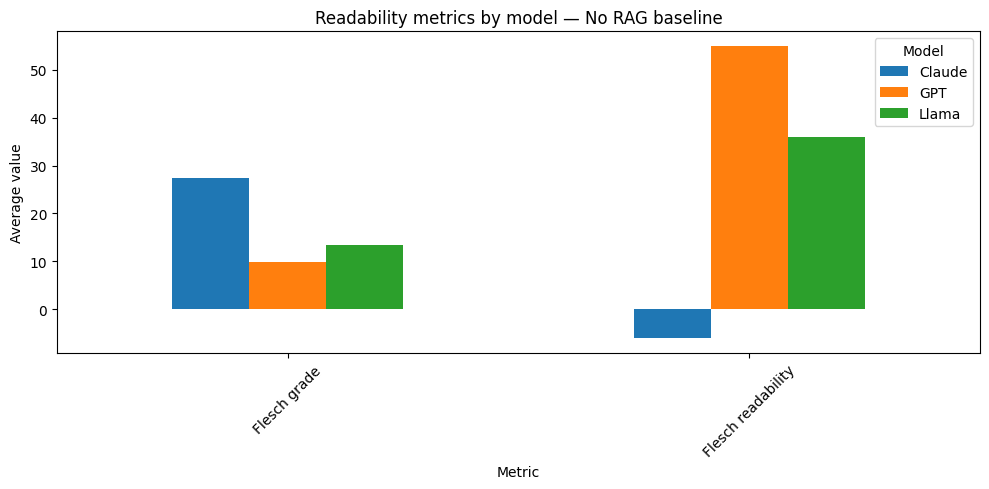

In [81]:
plot_group_for_file_group('No RAG baseline', 'Readability', figsize=(10, 5))


### No RAG baseline — Sentiment


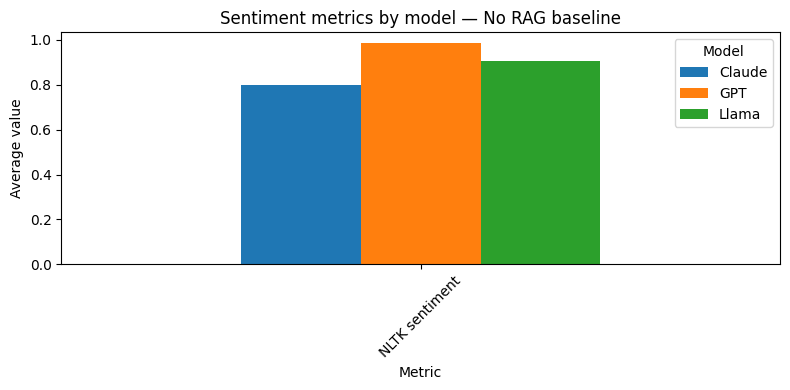

In [82]:
plot_group_for_file_group('No RAG baseline', 'Sentiment', figsize=(8, 4))
